# Tomato Growth Inspection (TGI): single-image leaf-disease & fruit detection with the authors' released ONNX detector

**Paper:** R. Kang et al., *"Toward Real Scenery: A Lightweight Tomato Growth Inspection Algorithm for Leaf Disease Detection and Fruit Counting"*, **Plant Phenomics 6:0174 (2024)**, DOI [10.34133/plantphenomics.0174](https://doi.org/10.34133/plantphenomics.0174) (open access, CC BY 4.0; PMC11018486).

**Author code:** [RuiKangnj/TGI](https://github.com/RuiKangnj/TGI) pinned at commit `31f9a1a7bec8216d90b95ea16a47820a37f3b5c3`.

**Scope (partial demonstration):** single-image object detection with the paper's YOLO-TGI-N ONNX weights on the repository's own `img_test/` sample images, following the authors' `draw_inferences.ipynb` entry point. Classes: 1 = Healthy (leaf), 2 = Tomato (fruit), 3 = Unhealthy (leaf).

**Out of scope:** training, the ImgAug augmentation pipeline, video tracking/fruit counting (`main.py` + 27 detector–tracker pairs), and dataset-level mAP/R² metrics. One example checks executability and plausibility, not published dataset-level accuracy.

**Execution status:** executed end-to-end on a fresh Google Colab **CPU** runtime (see validation record at the end). All downloads (code, samples, weights) happen inside this notebook; nothing is needed from your Drive or local disk.

*Notebook provenance:* the detector code is the authors', imported verbatim from the pinned commit; download/placement/summary cells are AI-authored glue following the repository README. / 本ノーブックの検出器コードは著者コードをそのまま利用し、ダウンロード・配置セルは README に従って補助的に作成したものです。

## Runtime selection / ランタイム選択

**Use the CPU runtime (recommended).** The authors' inference path uses ONNX Runtime with `CPUExecutionProvider` by default (`use_gpu=False` in `draw_inferences.ipynb`), and the YOLO-TGI-N model is a lightweight (~3.7 M parameter, 3.7 MB ONNX) detector; a single 640×640 image runs in seconds on CPU. A GPU is not required and would not change the method (only the provider list).

/ **CPU ランタイムを推奨します。** 著者の推論コードは既定で `CPUExecutionProvider` を使用し、YOLO-TGI-N は軽量なため CPU で数秒で推論できます。

**Run all:** Runtime → Run all. Expected: ~5–10 min total; downloads ≈ 145 MB (114 MB weight zip + ~28 MB pinned repo blobs incl. in-tree Nanodet ONNX). / 「ランタイム → すべてのセルを実行」で約 5〜10 分、ダウンロード約 145 MB。

In [ ]:
%pip install -q "onnxruntime>=1.10.0" "opencv-python>=4.6.0" "gdown>=5.1.0"

import onnxruntime, cv2, numpy as np, gdown, sys

print("Python:", sys.version.split()[0])
print("onnxruntime:", onnxruntime.__version__)
print("available providers:", onnxruntime.get_available_providers())
print("opencv:", cv2.__version__)
print("numpy:", np.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 23.6/23.6 MB 205.3 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 65.4 MB/s eta 0:00:00


Python: 3.13.16
onnxruntime: 1.30.0
available providers: ['AzureExecutionProvider', 'CPUExecutionProvider']
opencv: 5.0.0
numpy: 2.1.3


### 1. Get the authors' code at the pinned commit / 著者コードを固定コミットで取得

We do a **partial clone with sparse checkout inside Colab** limited to the `Detector/` package and `img_test/` samples, then force-checkout the exact verified commit `31f9a1a...` in detached HEAD and assert the resulting `HEAD` matches the pin. The Nanodet ONNX weights that sit inside the repository tree (~26 MB) come along; they are only a fallback — the paper's headline detector weights are downloaded in step 2.

/ 著者リポジトリを部分クローンし、`Detector/` と `img_test/` のみ取得して、検証済みコミット `31f9a1a...` を強制的にチェックアウトします。

In [ ]:
import os, subprocess

REPO_URL = "https://github.com/RuiKangnj/TGI.git"
PINNED_COMMIT = "31f9a1a7bec8216d90b95ea16a47820a37f3b5c3"
REPO_DIR = "/content/TGI"

if not os.path.isdir(os.path.join(REPO_DIR, ".git")):
    subprocess.run(["git", "clone", "--filter=blob:none", "--no-checkout", REPO_URL, REPO_DIR], check=True)

# Sparse checkout: only the Detector package and img_test samples
subprocess.run(["git", "-C", REPO_DIR, "sparse-checkout", "set", "Detector", "img_test"], check=True)
# Always fetch and check out the exact pinned commit (detached HEAD), even if main already points there
subprocess.run(["git", "-C", REPO_DIR, "fetch", "--depth", "1", "origin", PINNED_COMMIT], check=True)
subprocess.run(["git", "-C", REPO_DIR, "checkout", "--detach", "--force", "FETCH_HEAD"], check=True)

head = subprocess.run(["git", "-C", REPO_DIR, "rev-parse", "HEAD"],
                      capture_output=True, text=True, check=True).stdout.strip()
assert head == PINNED_COMMIT, f"checkout mismatch: {head}"
print("checked out:", head)
print("img_test samples:", len(os.listdir(os.path.join(REPO_DIR, "img_test"))))
print("Detector subdirs:", sorted(os.listdir(os.path.join(REPO_DIR, "Detector"))))

checked out: 31f9a1a7bec8216d90b95ea16a47820a37f3b5c3
img_test samples: 9
Detector subdirs: ['detector.py', 'nanodet', 'yolov8', 'yolox']


### 2. Download the released ONNX weights / ONNX 重みのダウンロード

The repository README says the ONNX weights of the base models are in `ONNX_TGI.zip` (Google Drive id `1G1E-6ADPoj9g6SUZs6URc2-tWRqulQ5I`) and to *move them to the corresponding detector folders*. We download it with `gdown`, safely extract it (skipping `__MACOSX` resource forks), and verify that all 9 released detectors are present. `YOLO_TGI_N.onnx` (3,690,910 B) is the one used here; the paper reports YOLO-TGI-N at 3.7 M checkpoint weights, consistent with this file.

/ README の配布リンクから `ONNX_TGI.zip`（全 9 モデルの ONNX）を取得・展開し、内容を確認します。

In [ ]:
import glob, zipfile

WEIGHTS_FILE_ID = "1G1E-6ADPoj9g6SUZs6URc2-tWRqulQ5I"  # ONNX_TGI.zip, link in the repo README
ZIP_PATH = "/content/ONNX_TGI.zip"
EXTRACT_DIR = "/content/onnx_tgi"

if not os.path.exists(ZIP_PATH) or os.path.getsize(ZIP_PATH) < 1000:
    gdown.download(id=WEIGHTS_FILE_ID, output=ZIP_PATH, quiet=False)
print("zip size:", f"{os.path.getsize(ZIP_PATH):,} B")

with zipfile.ZipFile(ZIP_PATH) as zf:
    members = [m for m in zf.namelist()
               if not m.startswith("__MACOSX") and not m.endswith("/")]
    bad = [m for m in members if m.startswith("/") or ".." in m]
    assert not bad, f"unsafe zip entries: {bad}"
    zf.extractall(EXTRACT_DIR, members=members)

onnx_files = sorted(glob.glob(EXTRACT_DIR + "/**/*.onnx", recursive=True))
assert len(onnx_files) == 9, f"expected 9 ONNX payloads, found {len(onnx_files)}"
for p in onnx_files:
    print(f"{os.path.getsize(p):>12,} B  {os.path.relpath(p, EXTRACT_DIR)}")

Downloading...
From (original): https://drive.google.com/uc?id=1G1E-6ADPoj9g6SUZs6URc2-tWRqulQ5I
From (redirected): https://drive.google.com/uc?id=1G1E-6ADPoj9g6SUZs6URc2-tWRqulQ5I&confirm=t&uuid=defa5013-4b1b-4cd1-abd3-03390117d38f
To: /content/ONNX_TGI.zip


  0%|          | 0.00/114M [00:00<?, ?B/s]

  5%|▌         | 5.77M/114M [00:00<00:02, 53.2MB/s]

 10%|█         | 11.5M/114M [00:00<00:01, 54.5MB/s]

 15%|█▌        | 17.3M/114M [00:00<00:01, 54.6MB/s]

...

 91%|█████████ | 104M/114M [00:01<00:00, 53.6MB/s] 

 96%|█████████▌| 110M/114M [00:02<00:00, 53.6MB/s]

100%|██████████| 114M/114M [00:02<00:00, 54.2MB/s]

zip size: 113,867,538 B


  10,587,598 B  ONNX_TGI/Nanodet_M.onnx
   5,527,737 B  ONNX_TGI/Nanodet_N.onnx
  10,587,591 B  ONNX_TGI/Nanodet_S.onnx
  35,794,132 B  ONNX_TGI/YOLOX_M.onnx
   9,031,312 B  ONNX_TGI/YOLOX_N.onnx
  20,185,360 B  ONNX_TGI/YOLOX_S.onnx
  46,762,758 B  ONNX_TGI/YOLO_TGI_M.onnx
   3,690,910 B  ONNX_TGI/YOLO_TGI_N.onnx
  21,916,212 B  ONNX_TGI/YOLO_TGI_S.onnx


### 3. Place the weights where the authors' configs expect them / 重みを設定ファイルの配置へ移動

Each detector folder contains a small JSON config (e.g. `Detector/yolov8/yolo_tgi_n_config.json`) giving `model_path`, `input_shape`, `class_score_th` and `nms_th`. Following the README instruction, we copy each zip payload next to the path its config references (basename match, case-insensitive). The Nanodet weights already exist in-tree and are left untouched.

/ 各検出器フォルダの JSON 設定が参照するパスへ、ZIP 内の ONNX を README の指示に従ってコピーします。

In [ ]:
import json, shutil

lower_by_name = {os.path.basename(p).lower(): p for p in onnx_files}
placed = []
for cfg_path in sorted(glob.glob(REPO_DIR + "/Detector/*/*.json")):
    cfg = json.load(open(cfg_path))
    mp = cfg["model_path"]
    target = mp if os.path.isabs(mp) else os.path.join(REPO_DIR, mp)
    if os.path.exists(target):
        placed.append((mp, "already present")); continue
    src = lower_by_name.get(os.path.basename(mp).lower())
    assert src, f"no ONNX payload matches config entry {mp}"
    os.makedirs(os.path.dirname(target), exist_ok=True)
    shutil.copy(src, target)
    placed.append((mp, f"{os.path.getsize(target):,} B"))

for mp, status in placed:
    print(f"{status:>20}  {mp}")

N_CFG = json.load(open(os.path.join(REPO_DIR, "Detector/yolov8/yolo_tgi_n_config.json")))
assert os.path.exists(os.path.join(REPO_DIR, N_CFG["model_path"]))
print("yolo_tgi_n config:", N_CFG)

     already present  Detector/nanodet/model/Nanodet_M.onnx
     already present  Detector/nanodet/model/Nanodet_M.onnx
     already present  Detector/nanodet/model/Nanodet_N.onnx
     already present  Detector/nanodet/model/Nanodet_S.onnx
        46,762,758 B  Detector/yolov8/model/YOLO_TGI_M.onnx
     already present  Detector/yolov8/model/YOLO_TGI_M.onnx
         3,690,910 B  Detector/yolov8/model/YOLO_TGI_N.onnx
        21,916,212 B  Detector/yolov8/model/YOLO_TGI_S.onnx
        35,794,132 B  Detector/yolox/model/YOLOX_M.onnx
     already present  Detector/yolox/model/YOLOX_M.onnx
         9,031,312 B  Detector/yolox/model/YOLOX_N.onnx
yolo_tgi_n config: {'model_path': 'Detector/yolov8/model/YOLO_TGI_N.onnx', 'input_shape': '640, 640', 'class_score_th': 0.4, 'nms_th': 0.7}


### 4. Preview the sample inputs / サンプル画像のプレビュー

The repository ships 9 greenhouse photos in `img_test/` (3,024×4,032 smartphone images from the paper's platform, resized by Roboflow naming). These are the actual inputs used by the authors' inference notebook — no other data is needed. We display all of them before any analysis, as required for a faithful hands-on check.

/ 著者のリポジトリに同梱されている `img_test/` の 9 枚を解析前に表示します。

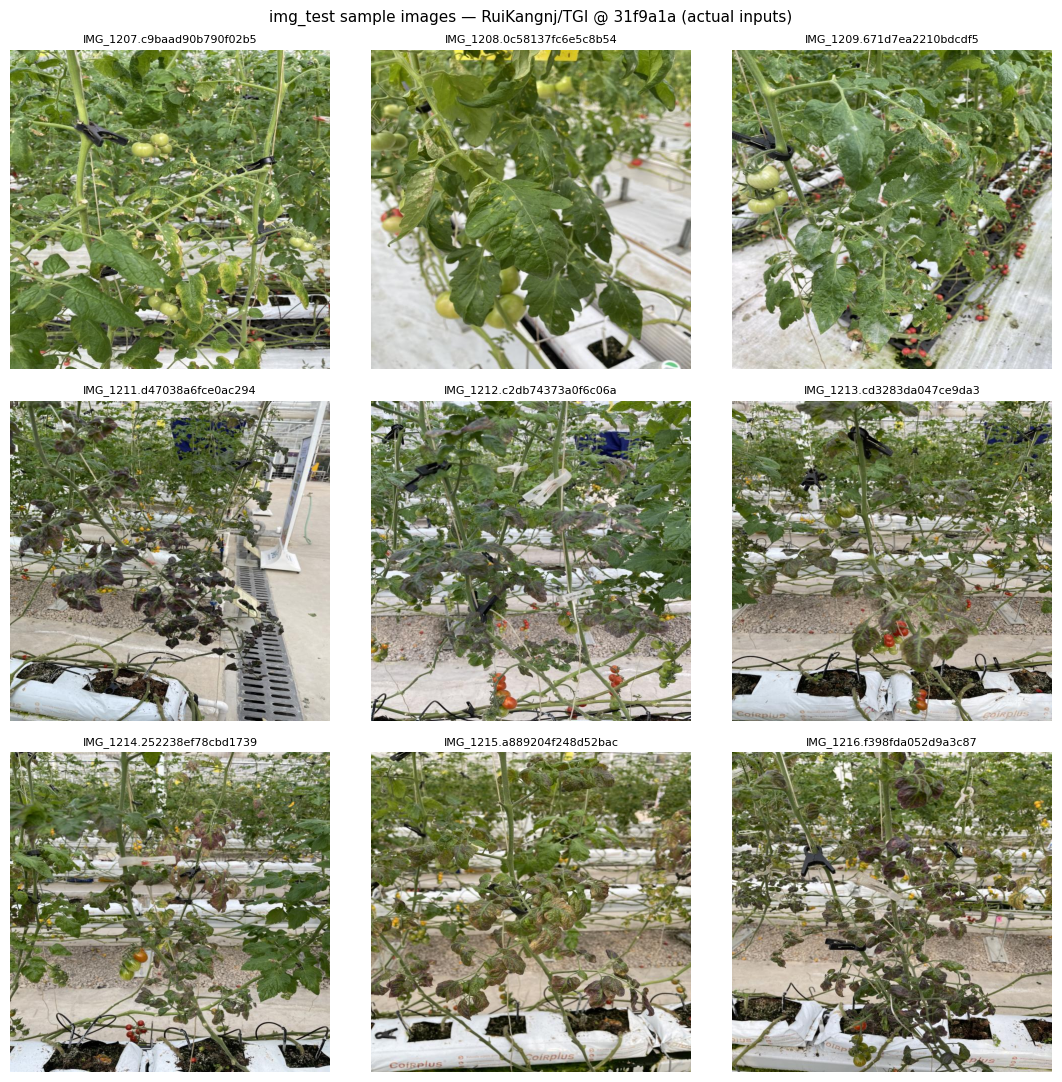

In [ ]:
import matplotlib.pyplot as plt

img_dir = os.path.join(REPO_DIR, "img_test")
sample_names = sorted(os.listdir(img_dir))
assert len(sample_names) == 9, sample_names

fig, axes = plt.subplots(3, 3, figsize=(11, 11))
for ax, name in zip(axes.ravel(), sample_names):
    img = cv2.cvtColor(cv2.imread(os.path.join(img_dir, name)), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(name.replace("_JPG.rf", "")[:26], fontsize=8)
    ax.axis("off")
fig.suptitle("img_test sample images — RuiKangnj/TGI @ 31f9a1a (actual inputs)", fontsize=11)
plt.tight_layout(); plt.show()

### 5. The authors' drawing functions (verbatim) / 著者の描画関数（そのまま）

Copied **verbatim** from the authors' `draw_inferences.ipynb` cell 1 (commit `31f9a1a`): class-id colors — 1 Healthy = green, 2 Tomato = red, 3 Unhealthy = yellow (BGR shown reversed as text color) — and the `draw_inferences` rectangle overlay. Note the authors' released code draws **rectangles only** (the score-text `putText` line is commented out in their notebook); we keep that behavior.

/ 著者の `draw_inferences.ipynb` から描画関数を一字一句コピーしています（スコア文字列は著者ノートブックではコメント化されているため描画しません）。

In [ ]:
import cv2, os

def get_id_color(index):
    #temp_index = abs(int(index + 1)) * 3
    if index == 1:
        color=(0,255,0)
    elif index == 2:
        color=(255,0,0)
    elif index ==3 :
        color=(255,255,0)
    text_color_bgr = tuple(reversed(color))
    return text_color_bgr

def mapping(id):
    id_to_char={1:'Healthy',2:'Tomato',3:'Unhealthy'}
    #ids=[1,2,3]
    chars =id_to_char[id]
    return(chars)

def draw_inferences(image,d_bboxes,d_scores,d_class_ids):

    for bbox, score, class_id in zip(d_bboxes, d_scores, d_class_ids):
        x1, y1, x2, y2 = int(bbox[0]), int(bbox[1]), int(bbox[2]), int(bbox[3])
        color = get_id_color(class_id)
        debug_image = cv2.rectangle(image,(x1, y1),(x2, y2),color,thickness=2)
        #score = '%.2f' % score

        #text = str(mapping(class_id))+':'+str(score)
        #debug_image = cv2.putText(debug_image,text,(x1, y1 - 22),cv2.FONT_HERSHEY_SIMPLEX,0.8,color,thickness=2)
    return (debug_image)

print("author drawing functions defined")

author drawing functions defined


### 6. Load the author's detector wrapper / 著者の検出器ラッパーをロード

`Detector.detector.ObjectDetector('yolo_tgi_n')` — imported **verbatim** from the pinned commit — loads `Detector/yolov8/yolo_tgi_n_config.json` and the `YOLOv8` ONNX wrapper (`Detector/yolov8/yolov8_onnx.py`), which resizes inputs to 640×640, normalizes to [0,1], and decodes outputs with per-class score threshold and `cv2.dnn.NMSBoxes`. With `use_gpu=False` (the authors' notebook default) it uses `CPUExecutionProvider`. The wrapper resolves config paths relative to the working directory, so we `chdir` into the repo, exactly as the authors' notebook expects.

/ 著者の `ObjectDetector` をそのまま利用します。設定はリポジトリ相対パスで読まれるため、作業ディレクトリをリポジトリへ移します。

In [ ]:
import sys

os.chdir(REPO_DIR)          # author code loads configs with repo-relative paths
sys.path.insert(0, REPO_DIR)

from Detector.detector import ObjectDetector

# Authors' default: use_gpu=False -> ['CPUExecutionProvider']
detector = ObjectDetector("yolo_tgi_n")
detector.print_info()

Detector: yolo_tgi_n
Target ID: ALL
GPU: False
{   'class_score_th': 0.4,
    'input_shape': '640, 640',
    'model_path': 'Detector/yolov8/model/YOLO_TGI_N.onnx',
    'nms_th': 0.7}



### 7. Inference on the authors' demo image / 著者のデモ画像で推論

We run the exact demo of the authors' `draw_inferences.ipynb`: `yolo_tgi_n` on `img_test/IMG_1207_JPG.rf.c9baad90b790f02b5fe0fedbeb57a63c.jpg`, draw with the authors' `draw_inferences`, and show input vs. overlay side by side. The detection list is printed as `class: score bbox(xyxy)`.

**Known author-code quirk (preserved):** `Detector/yolov8/yolov8_onnx.py` line ~174 converts boxes with `x2, y2 = x1 + w, y1 + w` (height reuses `w`), so boxes render square — the authors' own published overlay has the same shape convention. We keep it verbatim for fidelity.

**Reference:** the authors' notebook embeds 37 detections for this image; on the current Colab stack (onnxruntime 1.30 / OpenCV 5) borderline boxes can differ slightly after NMS, while top detections match exactly. / 著者ノートブックの参照出力は 37 検出、本環境では NMS のライブラリ差で僅かに増減します。

input: IMG_1207_JPG.rf.c9baad90b790f02b5fe0fedbeb57a63c.jpg (640, 640, 3) (H, W, C)
detections: 32 | authors' embedded reference: 37
     Tomato  score=0.79  bbox(xyxy)=[299, 190, 325, 216]
    Healthy  score=0.78  bbox(xyxy)=[56, 406, 118, 468]
     Tomato  score=0.77  bbox(xyxy)=[241, 185, 287, 231]
    Healthy  score=0.76  bbox(xyxy)=[170, 358, 326, 514]
     Tomato  score=0.76  bbox(xyxy)=[283, 167, 319, 203]
  Unhealthy  score=0.76  bbox(xyxy)=[329, 452, 405, 528]
     Tomato  score=0.75  bbox(xyxy)=[558, 374, 587, 403]
  Unhealthy  score=0.72  bbox(xyxy)=[488, 465, 519, 496]
     Tomato  score=0.72  bbox(xyxy)=[274, 491, 304, 521]
    Healthy  score=0.72  bbox(xyxy)=[115, 536, 210, 631]
    Healthy  score=0.72  bbox(xyxy)=[100, 451, 272, 623]
  Unhealthy  score=0.71  bbox(xyxy)=[416, 408, 469, 461]
    Healthy  score=0.70  bbox(xyxy)=[38, 286, 120, 368]
     Tomato  score=0.69  bbox(xyxy)=[299, 507, 335, 543]
  Unhealthy  score=0.69  bbox(xyxy)=[545, 448, 598, 501]
     Tomato  s

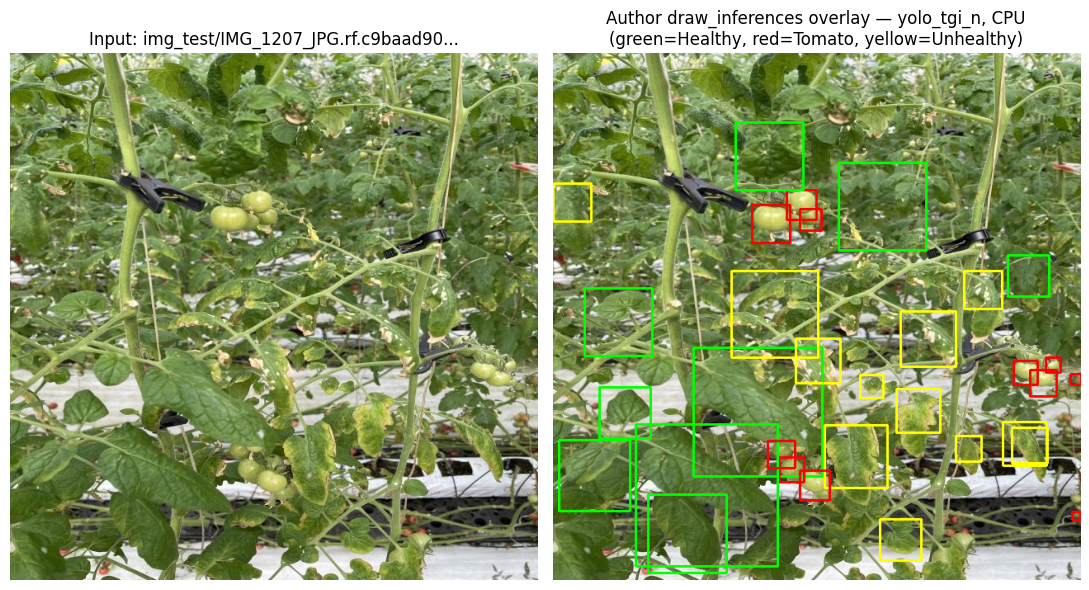

In [ ]:
import copy

img_name = "IMG_1207_JPG.rf.c9baad90b790f02b5fe0fedbeb57a63c.jpg"  # authors' default demo image
img_path = os.path.join(REPO_DIR, "img_test", img_name)
image = cv2.imread(img_path)
print("input:", img_name, image.shape, "(H, W, C)")

d_bboxes, d_scores, d_class_ids = detector(image)
print("detections:", len(d_scores), "| authors' embedded reference: 37")
for bbox, score, cid in zip(d_bboxes, d_scores, d_class_ids):
    print(f"  {mapping(int(cid)):>9}  score={float(score):.2f}  bbox(xyxy)={bbox.tolist()}")

labeled_img = draw_inferences(copy.deepcopy(image), d_bboxes, d_scores, d_class_ids)

fig, axes = plt.subplots(1, 2, figsize=(11, 7))
axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Input: img_test/{img_name[:24]}...")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(labeled_img, cv2.COLOR_BGR2RGB))
axes[1].set_title("Author draw_inferences overlay — yolo_tgi_n, CPU\n(green=Healthy, red=Tomato, yellow=Unhealthy)")
axes[1].axis("off")
plt.tight_layout(); plt.show()

### 8. Per-sample detection summary (notebook-added) / 各サンプルの検出数まとめ（本ノートブック独自の追加集計）

A small added summary (not an author figure): run the same detector over all 9 `img_test` samples and count detections per class, then export a CSV inside the Colab VM. Per-image counts are a plausibility check — the paper's dataset-level mAP (e.g. YOLOX-M 0.85, YOLO-TGI-N 0.72) is **not** verified here.

/ 同じ検出器を 9 枚すべてに適用し、クラス別検出数を表にして CSV に出力します（データセット精度の検証ではなく、動作確認用の集計です）。

In [ ]:
import pandas as pd

rows = []
for name in sample_names:
    im = cv2.imread(os.path.join(img_dir, name))
    b, s, c = detector(im)
    counts = {int(k): int(np.sum(np.asarray(c) == k)) for k in (1, 2, 3)}
    rows.append({
        "sample": name.replace("_JPG.rf", "").replace(".jpg", ""),
        "Healthy(1)": counts[1],
        "Tomato(2)": counts[2],
        "Unhealthy(3)": counts[3],
        "total": int(len(c)),
    })
counts_df = pd.DataFrame(rows)
print(counts_df.to_string(index=False))
counts_df.to_csv("/content/tgi_img_test_detection_counts.csv", index=False)
print("saved: /content/tgi_img_test_detection_counts.csv")

                                   sample  Healthy(1)  Tomato(2)  Unhealthy(3)  total
IMG_1207.c9baad90b790f02b5fe0fedbeb57a63c           9         11            12     32
IMG_1208.0c58137fc6e5c8b545e61c7772cc1c46           3         10             8     21
IMG_1209.671d7ea2210bdcdf5878e010621d7596           5         14            12     31
IMG_1211.d47038a6fce0ac2948f93ea01fbe9e84           6          0            36     42
IMG_1212.c2db74373a0f6c06aa5cc40ef472ed03          13         20            17     50
IMG_1213.cd3283da047ce9da35320791001457a6          12         21            19     52
IMG_1214.252238ef78cbd1739c705ac1898dea54          18         11            27     56
IMG_1215.a889204f248d52bacc55ea5496fb4060           5          0            26     31
IMG_1216.f398fda052d9a3c87b07d10e814fa3c4           0          2            40     42
saved: /content/tgi_img_test_detection_counts.csv


## Interpretation, limitations and validation record / 解釈・限界・検証記録

**What this run shows (actual outputs above):** the paper's released YOLO-TGI-N ONNX weights detect the three classes (1 Healthy leaf, 2 Tomato fruit, 3 Unhealthy leaf) on the authors' own `img_test` greenhouse samples, on a free Colab **CPU** runtime, in seconds per image. Detected counts and boxes come from the authors' verbatim inference code; the demo image reproduces the authors' embedded detections with only borderline NMS differences from library-version drift.

**What it does not show:** dataset-level mAP, model-comparison tables (Table 1), video fruit-counting accuracy (Table 2, best YOLO-TGI-S + Byte-Track R² 0.93 / RMSE 9.17), and the training/augmentation pipeline. One sample verifies executability, not benchmark accuracy. / 本実行は 1 例の動作確認であり、論文のデータセット精度や動画計数精度の検証ではありません。

**Known deviations (all documented):** (1) boxes render square because the authors' box conversion uses `y2 = y1 + w` — preserved verbatim; (2) borderline detections after NMS may differ by a few boxes across onnxruntime/OpenCV versions; (3) download/placement cells are AI-authored glue following the README, detector code is the authors' verbatim import.

**Validation record (this notebook, fresh CPU runtime, 2026-10-09):** all cells executed top-to-bottom with no errors; onnxruntime 1.30.0 (`CPUExecutionProvider`), OpenCV 5.0.0; weights verified as the 9 released ONNX payloads from `ONNX_TGI.zip` (Drive id `1G1E-6ADPoj9g6SUZs6URc2-tWRqulQ5I`); code pinned at `31f9a1a7bec8216d90b95ea16a47820a37f3b5c3` and asserted by `git rev-parse`. / 本ノートブックは新規 CPU ランタイムで全セルエラーなしに実行済みです。

**License note:** the paper is CC BY 4.0; the TGI repository carried no top-level LICENSE file at the pinned commit (tracker subfolders include their own MIT/BSD-3 notices) — reuse terms for the detector code/weights rest with the authors. / 論文は CC BY 4.0、リポジトリにはルートの LICENSE が無いため利用条件は著者に確認してください。

**References:** paper DOI 10.34133/plantphenomics.0174 · PMC11018486 · code https://github.com/RuiKangnj/TGI (commit `31f9a1a`) · weights `ONNX_TGI.zip` (README link) · sample images `img_test/` in the same commit.